# Seed + WinRate: Optuna e validação temporal

Este experimento usa somente **SeedDif e WinRateDiff**. Busca uma configuração de
regressão linear, Random Forest e XGBoost pela menor média anual do Logistic Brier.

Validamos nos últimos cinco anos: **2021, 2022, 2023, 2024 e 2025**.

Em cada ano, o modelo treina somente nos anos anteriores. Uma configuração é
compartilhada pelas categorias, mas masculino e feminino têm ajustes separados.
O score de cada ano reúne os jogos das duas categorias; a média dá o mesmo peso
aos cinco anos. Depois da seleção, treinamos até 2025 e geramos três CSVs de 2026.

Os anos de validação também selecionam os hiperparâmetros: estes resultados são
scores da busca, não uma avaliação em um conjunto de teste independente.


## Configuração e espaços de busca

Regressão linear: duas possibilidades de intercepto, enumeradas com GridSampler.
Random Forest e XGBoost: 30 tentativas cada, com TPESampler e semente fixa.
Todas as tentativas avaliam todos os anos, sem pruning.

Para ampliar a busca, altere `N_TRIALS`; para mudar os intervalos, altere
`ESPACOS`. Reexecutar inicia estudos novos e atualiza os arquivos deste experimento.

[Documentação do Optuna](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.create_study.html).


In [1]:
from pathlib import Path
import sys
import json
from importlib.metadata import version

import numpy as np
import pandas as pd
import optuna
from IPython.display import display

pasta_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [pasta_atual, *pasta_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data não encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds, calcular_winrate, adicionar_winrate
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.tuning import otimizar_modelo
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

EXPERIMENTO = "seed_winrate_optuna"
FEATURES = ["SeedDif", "WinRateDiff"]
ANOS_VALIDACAO = list(range(2021, 2026))
TEMPORADA_PREVISAO = 2026
SEED = 42
N_JOBS_MODELO = 2
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
CRIADORES = {
    "linear": criar_regressao_linear,
    "random_forest": criar_random_forest,
    "xgboost": criar_xgboost,
}
NOMES = {"linear": "Regressão linear", "random_forest": "Random Forest", "xgboost": "XGBoost"}
N_TRIALS = {"linear": 2, "random_forest": 30, "xgboost": 30}
PARAMETROS_FIXOS = {
    "linear": {},
    "random_forest": {"random_state": SEED, "n_jobs": N_JOBS_MODELO},
    "xgboost": {
        "random_state": SEED, "n_jobs": N_JOBS_MODELO,
        "objective": "reg:squarederror", "tree_method": "hist",
    },
}
ESPACOS = {
    "linear": {
        "fit_intercept": {"tipo": "categorical", "choices": [False, True]},
    },
    "random_forest": {
        "n_estimators": {"tipo": "int", "low": 150, "high": 500, "step": 50},
        "max_depth": {"tipo": "categorical", "choices": [2, 3, 4, 6, 8, 12, None]},
        "min_samples_leaf": {"tipo": "int", "low": 2, "high": 80, "log": True},
        "max_features": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "max_samples": {"tipo": "float", "low": 0.6, "high": 1.0},
    },
    "xgboost": {
        "n_estimators": {"tipo": "int", "low": 100, "high": 600, "step": 50},
        "max_depth": {"tipo": "int", "low": 1, "high": 5},
        "learning_rate": {"tipo": "float", "low": 0.01, "high": 0.15, "log": True},
        "min_child_weight": {"tipo": "float", "low": 5.0, "high": 80.0, "log": True},
        "subsample": {"tipo": "float", "low": 0.6, "high": 1.0},
        "colsample_bytree": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "reg_alpha": {"tipo": "float", "low": 0.00001, "high": 10.0, "log": True},
        "reg_lambda": {"tipo": "float", "low": 0.1, "high": 100.0, "log": True},
        "gamma": {"tipo": "float", "low": 0.0, "high": 5.0},
    },
}
PASTA_RESULTADOS = raiz / "results" / EXPERIMENTO
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)


## Preparação e cortes temporais

Win rate é a proporção de vitórias na temporada regular do mesmo ano.
Usamos o histórico completo anterior ao ano validado, sem divisão aleatória.
A temporada regular de 2026 é usada somente para as features da submissão:
os resultados do torneio de 2026 nunca entram no treino ou na seleção.

Para 2026, restringimos a temporada regular aos dias anteriores ao início habitual
do torneio (DayNum 134). Também conferimos a separação regular/torneio em cada ano histórico.


In [2]:
dados = {
    categoria: carregar_dados(raiz / "raw_data", categoria, incluir_regular=True)
    for categoria in CATEGORIAS
}
seeds, winrates, jogos = {}, {}, {}
for categoria, base in dados.items():
    resultados = base["resultados"].loc[base["resultados"]["Season"] < TEMPORADA_PREVISAO]
    regulares = base["temporada_regular"].loc[
        (base["temporada_regular"]["Season"] < TEMPORADA_PREVISAO)
        | (
            base["temporada_regular"]["Season"].eq(TEMPORADA_PREVISAO)
            & base["temporada_regular"]["DayNum"].lt(134)
        )
    ]
    calendario = resultados.groupby("Season")["DayNum"].min().to_frame("InicioTorneio").join(
        regulares.groupby("Season")["DayNum"].max().rename("FimRegular")
    )
    assert calendario.notna().all().all()
    assert (calendario["FimRegular"] < calendario["InicioTorneio"]).all()
    seeds[categoria] = preparar_seeds(base["seeds"])
    winrates[categoria] = calcular_winrate(regulares)
    jogos[categoria] = adicionar_winrate(
        adicionar_seeds(organizar_jogos(resultados), seeds[categoria]),
        winrates[categoria],
    )

for ano in ANOS_VALIDACAO:
    if not all(tabela["Season"].eq(ano).any() for tabela in jogos.values()):
        raise ValueError(f"Faltam jogos para validar em {ano}.")
print(f"Validação nos últimos cinco anos: {ANOS_VALIDACAO}")

divisoes = pd.DataFrame([
    {
        "AnoValidacao": ano, "Categoria": CATEGORIAS[categoria],
        "UltimoAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].max(),
        "JogosTreino": tabela["Season"].lt(ano).sum(),
        "JogosValidacao": tabela["Season"].eq(ano).sum(),
    }
    for ano in ANOS_VALIDACAO for categoria, tabela in jogos.items()
])
display(divisoes)
display(jogos["M"][[
    "Season", "TeamA", "TeamB", "SeedDif", "WinRateDiff", "Target",
]].head())
divisoes.to_csv(PASTA_RESULTADOS / "divisoes_temporais.csv", index=False)


Validação nos últimos cinco anos: [2021, 2022, 2023, 2024, 2025]


,AnoValidacao,Categoria,UltimoAnoTreino,JogosTreino,JogosValidacao
0,2021,Masculino,2019,2251,66
1,2021,Feminino,2019,1386,63
2,2022,Masculino,2021,2317,67
3,2022,Feminino,2021,1449,67
4,2023,Masculino,2022,2384,67
5,2023,Feminino,2022,1516,67
6,2024,Masculino,2023,2451,67
7,2024,Feminino,2023,1583,67
8,2025,Masculino,2024,2518,67
9,2025,Feminino,2024,1650,67


,Season,TeamA,TeamB,SeedDif,WinRateDiff,Target
0,1985,1116,1234,1,-0.030303,9
1,1985,1120,1345,5,-0.059310,1
2,1985,1207,1250,-15,0.546616,25
3,1985,1229,1425,1,0.062169,3
4,1985,1242,1325,-11,0.025926,11


## Busca e seleção pela média dos cinco anos

Cada tentativa treina dez modelos: duas categorias para cada um dos cinco anos.
Uma única configuração vence por família. Não escolhemos uma configuração diferente
para cada ano. Os estudos, previsões e scores são salvos para inspeção.


In [3]:
buscas = {}
for nome, criar_modelo in CRIADORES.items():
    sampler = (
        optuna.samplers.GridSampler({"fit_intercept": [False, True]}, seed=SEED)
        if nome == "linear" else optuna.samplers.TPESampler(seed=SEED)
    )
    buscas[nome] = otimizar_modelo(
        jogos, criar_modelo, ESPACOS[nome], ANOS_VALIDACAO,
        features=FEATURES, n_trials=N_TRIALS[nome],
        parametros_fixos=PARAMETROS_FIXOS[nome], sampler=sampler,
        seed=SEED, nome=nome,
    )
    resultado = buscas[nome]
    resultado["estudo"].trials_dataframe().to_csv(
        PASTA_RESULTADOS / f"tentativas_{nome}.csv", index=False,
    )
    resultado["previsoes"].to_csv(
        PASTA_RESULTADOS / f"previsoes_validacao_{nome}.csv", index=False,
    )
    resultado["resultados"].to_csv(
        PASTA_RESULTADOS / f"scores_anuais_{nome}.csv", index=False,
    )
    (PASTA_RESULTADOS / f"melhores_parametros_{nome}.json").write_text(
        json.dumps(resultado["parametros"], ensure_ascii=False, indent=2, allow_nan=False),
        encoding="utf-8",
    )

resumo = pd.DataFrame([
    {
        "Modelo": NOMES[nome], "MediaLogisticBrier": resultado["media"],
        "MelhorTrial": resultado["estudo"].best_trial.number,
        "Tentativas": len(resultado["estudo"].trials),
        "Parametros": json.dumps(resultado["parametros"], ensure_ascii=False),
    }
    for nome, resultado in buscas.items()
]).sort_values("MediaLogisticBrier")
display(resumo)
for nome, resultado in buscas.items():
    print(NOMES[nome], resultado["parametros"])
resumo.to_csv(PASTA_RESULTADOS / "resumo_melhores.csv", index=False)


linear: 2/2; melhor média = 0.074187
random_forest: 5/30; melhor média = 0.072473
random_forest: 10/30; melhor média = 0.071941
random_forest: 15/30; melhor média = 0.071531
random_forest: 20/30; melhor média = 0.071531
random_forest: 25/30; melhor média = 0.071531
random_forest: 30/30; melhor média = 0.071398
xgboost: 5/30; melhor média = 0.071738
xgboost: 10/30; melhor média = 0.069873
xgboost: 15/30; melhor média = 0.069873
xgboost: 20/30; melhor média = 0.069873
xgboost: 25/30; melhor média = 0.069873
xgboost: 30/30; melhor média = 0.069821
Regressão linear {'fit_intercept': True}
Random Forest {'random_state': 42, 'n_jobs': 2, 'n_estimators': 150, 'max_depth': 4, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_samples': 0.7047788912373731}
XGBoost {'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 350, 'max_depth': 1, 'learning_rate': 0.015533475780068709, 'min_child_weight': 28.39153426673116, 'subsample': 0.9278170389008983

,Modelo,MediaLogisticBrier,MelhorTrial,Tentativas,Parametros
2,XGBoost,0.069821,29,30,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."
1,Random Forest,0.071398,28,30,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
0,Regressão linear,0.074187,0,2,"{""fit_intercept"": true}"


## Evolução anual da melhor configuração de cada modelo

Cada linha mantém os mesmos hiperparâmetros nos cinco anos; os pesos/árvores são
reajustados com o histórico disponível em cada corte. A média simples destes
cinco pontos é exatamente a métrica usada pelo Optuna.


Modelo,Random Forest,Regressão linear,XGBoost
Season,,,
2021,0.085356,0.089430,0.081805
2022,0.080982,0.087831,0.081945
2023,0.076038,0.077149,0.074626
2024,0.057411,0.060969,0.056510
2025,0.057201,0.055558,0.054219


Modelo            Random Forest  Regressão linear   XGBoost
Season Categoria                                           
2021   M               0.098511          0.105780  0.094637
       W               0.071574          0.072302  0.068362
2022   M               0.087789          0.095174  0.085484
       W               0.074175          0.080488  0.078405
2023   M               0.083672          0.081883  0.080697
       W               0.068404          0.072414  0.068555
2024   M               0.074055          0.078923  0.073207
       W               0.040767          0.043016  0.039813
2025   M               0.056432          0.056958  0.055099
       W               0.057970          0.054158  0.053338

cell_8:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


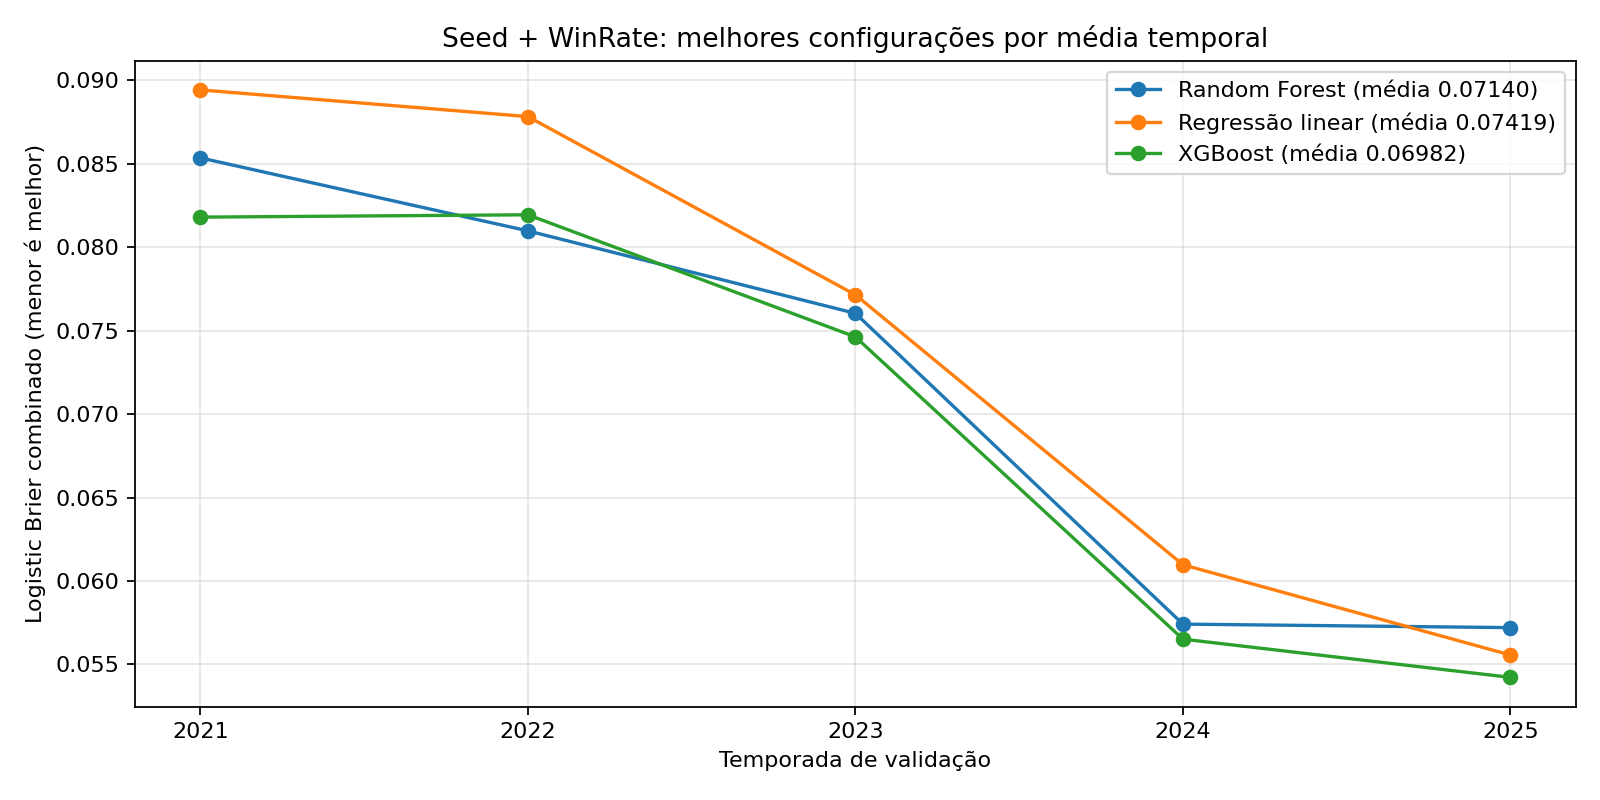

In [4]:
import matplotlib.pyplot as plt

scores_anuais = pd.concat([
    resultado["resultados"].assign(Modelo=NOMES[nome])
    for nome, resultado in buscas.items()
], ignore_index=True)
tabela_grafico = scores_anuais.loc[scores_anuais["Categoria"].eq("Combinado")].pivot(
    index="Season", columns="Modelo", values="Score",
)
display(tabela_grafico.round(6))
display(scores_anuais.loc[~scores_anuais["Categoria"].eq("Combinado")].pivot(
    index=["Season", "Categoria"], columns="Modelo", values="Score",
).round(6))

fig, ax = plt.subplots(figsize=(10, 5))
for modelo in tabela_grafico.columns:
    valores = tabela_grafico[modelo]
    ax.plot(valores.index, valores, marker="o", label=f"{modelo} (média {valores.mean():.5f})")
ax.set_title("Seed + WinRate: melhores configurações por média temporal")
ax.set_xlabel("Temporada de validação")
ax.set_ylabel("Logistic Brier combinado (menor é melhor)")
ax.set_xticks(ANOS_VALIDACAO)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_RESULTADOS / "melhores_configuracoes_por_ano.png", dpi=160)
plt.show()
scores_anuais.to_csv(PASTA_RESULTADOS / "scores_anuais_melhores.csv", index=False)


## Treino final e três submissões de 2026

Para cada família, criamos modelos novos com os hiperparâmetros vencedores e
treinamos masculino e feminino com todos os resultados disponíveis até 2025.
Os confrontos de 2026 usam as mesmas duas features.

Preservamos todos os IDs do sample. Pares envolvendo times sem seed recebem zero,
como no baseline. Todo par entre participantes deve ter win rate disponível.
Pred é uma margem de pontos; não aplicamos sigmoide no CSV.


In [5]:
sample_submission = dados["M"]["sample_submission"]
confrontos = preparar_confrontos(
    sample_submission, seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
confrontos = adicionar_winrate(
    confrontos, pd.concat(list(winrates.values()), ignore_index=True),
    permitir_ausentes=True,
)
participantes = confrontos["TemDuasSeeds"]
assert np.isfinite(confrontos.loc[participantes, FEATURES].to_numpy()).all()
assert participantes.sum() == 2 * (68 * 67 // 2)

modelos_finais = {}
arquivos_submission = {}
resumo_submissions = []
for nome, criar_modelo in CRIADORES.items():
    modelos_finais[nome] = {}
    for categoria, tabela in jogos.items():
        treino = tabela.loc[tabela["Season"] < TEMPORADA_PREVISAO]
        assert treino["Season"].max() == 2025
        modelo = criar_modelo(**buscas[nome]["parametros"])
        modelo.fit(treino[FEATURES], treino["Target"])
        modelos_finais[nome][categoria] = modelo

    previsoes = prever_confrontos(
        confrontos, modelos_finais[nome]["M"], modelos_finais[nome]["W"],
        features=FEATURES,
    )
    caminho = salvar_submission(
        previsoes, sample_submission,
        raiz / "submissions" / f"submission_seed_winrate_optuna_{nome}_{TEMPORADA_PREVISAO}.csv",
    )
    arquivos_submission[nome] = caminho
    resumo_submissions.append({
        "Modelo": NOMES[nome], "Arquivo": caminho.name,
        "Linhas": len(previsoes), "ParesParticipantes": int(participantes.sum()),
        "MinPred": previsoes["Pred"].min(), "MaxPred": previsoes["Pred"].max(),
    })
display(pd.DataFrame(resumo_submissions))


,Modelo,Arquivo,Linhas,ParesParticipantes,MinPred,MaxPred
0,Regressão linear,submission_seed_winrate_optuna_linear_2026.csv,132133,4556,-38.703786,41.357228
1,Random Forest,submission_seed_winrate_optuna_random_forest_2...,132133,4556,-37.930754,44.302728
2,XGBoost,submission_seed_winrate_optuna_xgboost_2026.csv,132133,4556,-27.544708,34.800137


## Registro para reprodução

O registro inclui os espaços de busca, parâmetros fixos, parâmetros vencedores,
sementes e versões das bibliotecas. As três submissões são arquivos locais
prontos para envio; este notebook não envia nada ao Kaggle.


In [6]:
registro = {
    "experimento": EXPERIMENTO,
    "features": FEATURES,
    "anos_validacao": ANOS_VALIDACAO,
    "temporada_previsao": TEMPORADA_PREVISAO,
    "objetivo": "Media simples dos cinco scores anuais; jogos M/W combinados em cada ano",
    "n_trials": N_TRIALS,
    "seed": SEED,
    "espacos_busca": ESPACOS,
    "parametros_fixos": PARAMETROS_FIXOS,
    "melhores_parametros": {nome: resultado["parametros"] for nome, resultado in buscas.items()},
    "melhores_medias": {nome: resultado["media"] for nome, resultado in buscas.items()},
    "arquivos_submission": {nome: str(path.relative_to(raiz)) for nome, path in arquivos_submission.items()},
    "versoes": {
        pacote: version(pacote)
        for pacote in ["numpy", "pandas", "scikit-learn", "xgboost", "optuna"]
    },
}
(PASTA_RESULTADOS / "configuracao.json").write_text(
    json.dumps(registro, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8",
)
print(f"Resultados e gráfico: {PASTA_RESULTADOS}")
for nome, caminho in arquivos_submission.items():
    print(f"{NOMES[nome]}: {caminho}")


Resultados e gráfico: C:\Users\davis\Documents\vscode\March-Mania---Comp-CDados\results\seed_winrate_optuna
Regressão linear: C:\Users\davis\Documents\vscode\March-Mania---Comp-CDados\submissions\submission_seed_winrate_optuna_linear_2026.csv
Random Forest: C:\Users\davis\Documents\vscode\March-Mania---Comp-CDados\submissions\submission_seed_winrate_optuna_random_forest_2026.csv
XGBoost: C:\Users\davis\Documents\vscode\March-Mania---Comp-CDados\submissions\submission_seed_winrate_optuna_xgboost_2026.csv
